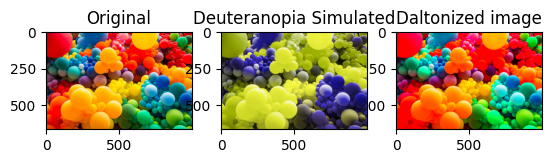

In [1]:
#MACHADO STYLE DALTONIZATION
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load image using opencv
image=cv2.imread('/Users/vithikasurve/Desktop/ML/balloons (1).jpg')

# Convert to RGB and normalize
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#Normalization
image_rgb = image_rgb / 255.0

#Deuteranopia Simulation Matrix (Machado Matrix)
DEUTERANOPIA_SIM = np.array([
    [0.625, 0.375, 0.000],
    [0.700, 0.300, 0.000],
    [0.000, 0.300, 0.700]
])

# Convert the image to the deuteranopia color space
converted_img = np.tensordot(image_rgb, DEUTERANOPIA_SIM.T, axes=1)
converted_img = np.clip(converted_img, 0, 1)

# Convert to uint8 for display
converted = (converted_img * 255).astype(np.uint8)

#Calculate error
error=image_rgb-converted_img

#Daltonized
daltonized=image_rgb+0.7*error
daltonized=np.clip(daltonized,0,1)

#Display daltonized
daltonized_uint8 = (daltonized * 255).astype(np.uint8)
plt.subplot(1,3,3)
plt.imshow(daltonized_uint8)
plt.title("Daltonized image")

#Display images using Matplotlib
plt.subplot(1,3,1)
plt.imshow((image_rgb * 255).astype(np.uint8))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(converted)
plt.title("Deuteranopia Simulated")

plt.show()

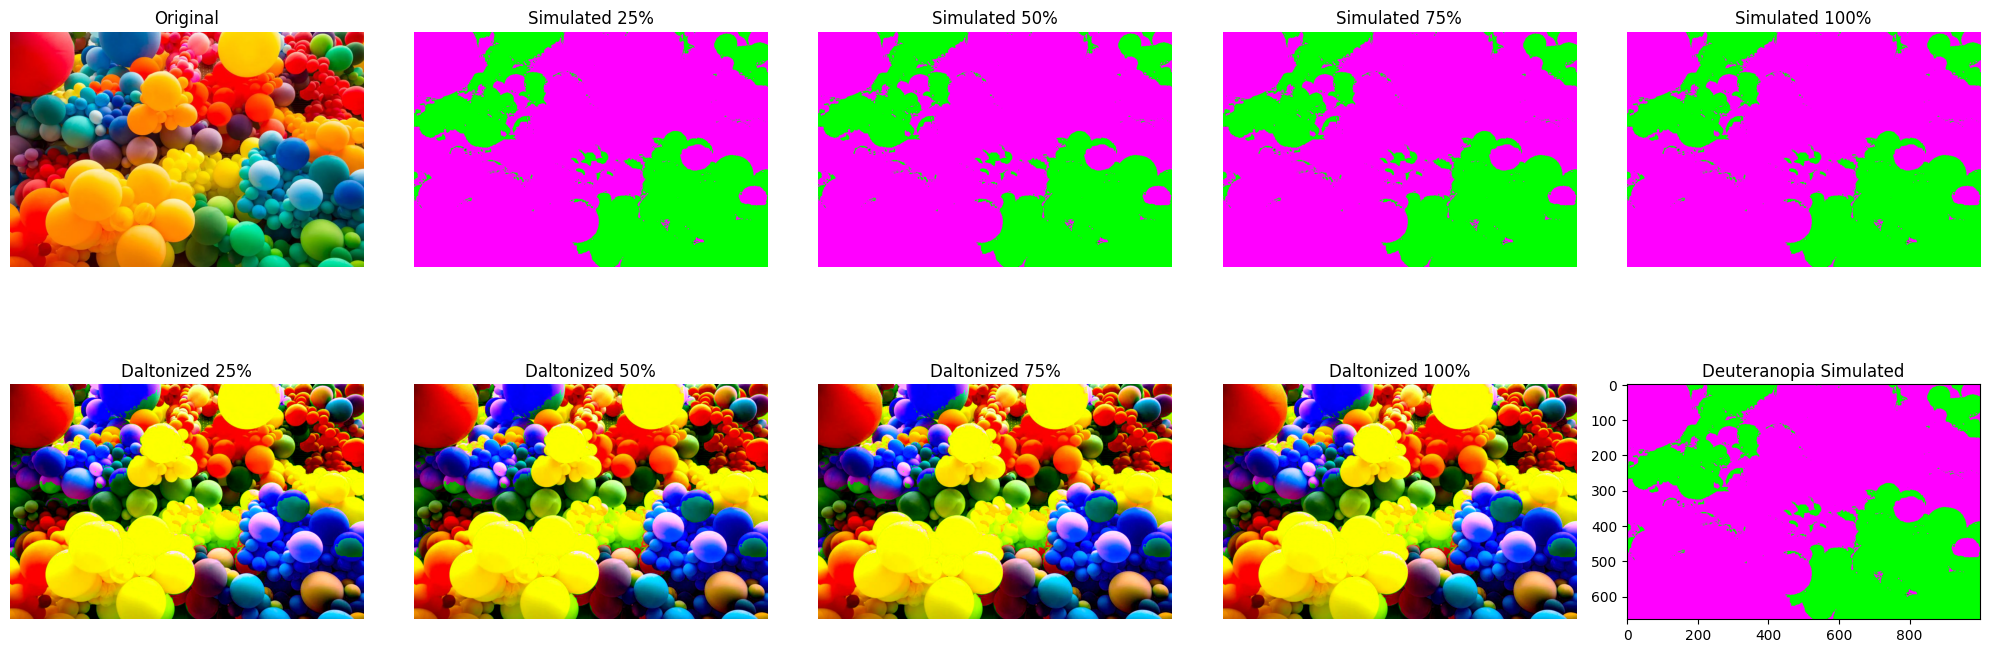

In [2]:
#WITHOUT HARDCORE MATRIX (severity)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from colorspacious import cspace_converter

#Load image using opencv
image=cv2.imread('/Users/vithikasurve/Desktop/ML/balloons (1).jpg')
#Convert to RBG
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#Normalization
image_rgb = image_rgb / 255.0

#Reshape, Flatten image to (height*width, 3) for color transformation
h, w, _ = image_rgb.shape
flat_rgb = image_rgb.reshape(-1, 3)

# Create list to store results
simulated_list = []
daltonized_list = []
severities = [25, 50, 75, 100]
for severity in severities:
    # Apply color correction
    target_space = {
    "name": "sRGB1+CVD",
    "cvd_type": "deuteranomaly",
    "severity": 100
    }
    # Now use normal source, fancy target
    converter = cspace_converter("sRGB1", target_space)
    simulated=converter(flat_rgb)
    # Convert the image to the deuteranopia color space
    simulated_img = simulated.reshape(h, w, 3)
    simulated_img = np.clip(simulated_img, 0, 1)
    simulated_list.append((severity, (simulated_img * 255).astype(np.uint8)))
    # Calculate error
    error = image_rgb - simulated_img
    # Daltonize
    daltonized = image_rgb + 0.7 * error
    daltonized = np.clip(daltonized, 0, 1)
    daltonized_list.append((severity, (daltonized * 255).astype(np.uint8)))

# Plotting in 2x5 Grid
plt.figure(figsize=(20, 8))

# Row 1: Original + Simulations
plt.subplot(2, 5, 1)
plt.imshow((image_rgb * 255).astype(np.uint8))
plt.title("Original")
plt.axis('off')

for idx, (severity, sim_img) in enumerate(simulated_list):
    plt.subplot(2, 5, idx + 2)
    plt.imshow(sim_img)
    plt.title(f"Simulated {severity}%")
    plt.axis('off')
# Row 2: Daltonized Versions
for idx, (severity, dal_img) in enumerate(daltonized_list):
    plt.subplot(2, 5, idx + 6)
    plt.imshow(dal_img)
    plt.title(f"Daltonized {severity}%")
    plt.axis('off')

# Convert to uint8 for display
# Display or convert back
converted = (simulated_img * 255).astype(np.uint8)
plt.subplot(2,5,10)
plt.imshow(converted)
plt.title("Deuteranopia Simulated")

plt.tight_layout()

plt.show()

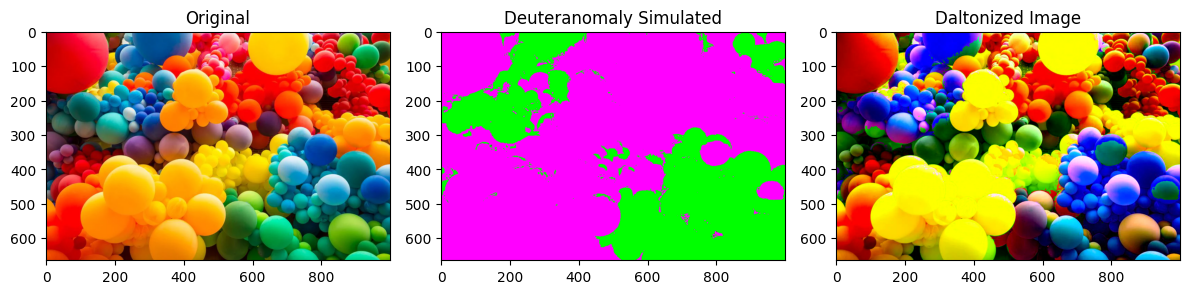

In [3]:
#WITHOUT HARDCORE MATRIX
import cv2
import numpy as np
import matplotlib.pyplot as plt
from colorspacious import cspace_converter

# Load image using OpenCV
image = cv2.imread('/Users/vithikasurve/Desktop/ML/balloons (1).jpg')

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# Normalize RGB to [0, 1]
image_rgb = image_rgb / 255.0

# Flatten image to (height*width, 3) for color transformation
h, w, _ = image_rgb.shape
flat_rgb = image_rgb.reshape(-1, 3)

# Configure Deuteranomaly simulation without Hardcore matrix
target_space = {
    "name": "sRGB1+CVD",
    "cvd_type": "deuteranomaly",  # ✅ THIS is the correct keyword
    "severity": 100               # Maximum severity (100%)
}

# Convert using colorspacious
converter = cspace_converter("sRGB1", target_space)
simulated_flat = converter(flat_rgb)
simulated_img = simulated_flat.reshape(h, w, 3)
simulated_img = np.clip(simulated_img, 0, 1)

# Calculate the error and daltonize
error = image_rgb - simulated_img
daltonized = image_rgb + 0.7 * error
daltonized = np.clip(daltonized, 0, 1)

# Convert images back to uint8 for display
original_uint8 = (image_rgb * 255).astype(np.uint8)
simulated_uint8 = (simulated_img * 255).astype(np.uint8)
daltonized_uint8 = (daltonized * 255).astype(np.uint8)

# Display images using Matplotlib
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_uint8)
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(simulated_uint8)
plt.title("Deuteranomaly Simulated")

plt.subplot(1, 3, 3)
plt.imshow(daltonized_uint8)
plt.title("Daltonized Image")

plt.tight_layout()
plt.show()



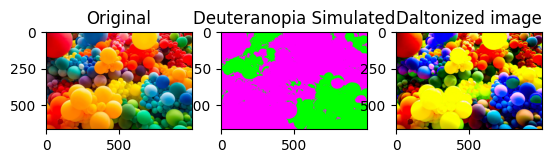

<Figure size 1200x400 with 0 Axes>

In [4]:
#WITHOUT HARDCORE MATRIX (my code)
import cv2
import numpy as np
import matplotlib.pyplot as plt
from colorspacious import cspace_converter

#Load image using opencv
image=cv2.imread('/Users/vithikasurve/Desktop/ML/balloons (1).jpg')
#Convert to RBG
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#Normalization
image_rgb = image_rgb / 255.0

#Reshape, Flatten image to (height*width, 3) for color transformation
h, w, _ = image_rgb.shape
flat_rgb = image_rgb.reshape(-1, 3)

#Without a hardcore matrix Using Colorspacious
target_space = {
    "name": "sRGB1+CVD",
    "cvd_type": "deuteranomaly",
    "severity": 100
}

# Now use normal source, fancy target
converter = cspace_converter("sRGB1", target_space)
simulated=converter(flat_rgb)
# Convert the image to the deuteranopia color space
simulated_img = simulated.reshape(h, w, 3)
simulated_img = np.clip(simulated_img, 0, 1)

# Convert to uint8 for display
converted = (simulated_img * 255).astype(np.uint8)
plt.subplot(1,3,2)
plt.imshow(converted)
plt.title("Deuteranopia Simulated")

# Calculate error
error = image_rgb - simulated_img
# Daltonize
daltonized = image_rgb + 0.7 * error
daltonized = np.clip(daltonized, 0, 1)

# Display or convert back
daltonized_uint8 = (daltonized * 255).astype(np.uint8)
plt.subplot(1,3,3)
plt.imshow(daltonized_uint8)
plt.title("Daltonized image")

#Display images using Matplotlib
plt.subplot(1,3,1)
plt.imshow((image_rgb * 255).astype(np.uint8))
plt.title("Original")

# Display images using Matplotlib
plt.figure(figsize=(12, 4))

plt.tight_layout()

plt.show()